<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/pivot-point-driven-pendulum-M0nkey-M4n/blob/main/pivot-point-driven-pendulum-assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Pseudocode:
1. **Import modules:** Import `numpy as np`, `scipy.integrate` for `solve_ivp`, and `matplotlib.plot as plt` for plotting, and `matplotlib.animate` for animating the pendulum.
2. **Define our equation of motion:** define a function `pivot_driven_pendulum(t, y, omega_d, g=1, l=1, gamme=0, x_p0=1, and y_p0=1)` where `t` and `y` are the time and state variables, respectively; `omega_d` is the driving frequency; `omega_0 = g/l = 1` is the natural frequency; `gamma=0` is the damping coefficient; `[x_p0, y_p0]` are the maximum deflection values for the pivot point in x and y.
  * The equation of motion is:
$$\ddot{\theta} + 2 \gamma \dot{\theta} + \omega_0^2 sin(\theta) - \omega_d^2sin(\theta - \omega_dt) = 0$$  
  * The pivot motion is paramterized by these two equations:
  $$x_p(t) = -lsin(\omega_dt)$$
  $$y_p(t) = l(cos(\omega_dt) - 1)$$
3. **Define utilities:**
  * The `get_pivot_xy(t, omega_d, x_p0, y_p0)` utility gives `x_p` and `y_p`, the position of the pivot point.
  * The `get_pendulum_xy(t, theta, l)` utility gives `x_pendulum` and `y_pendulum`, the position of the pendulum bob referenced to the pivot point.
  * The `get_lab_xy(x_p, y_p, x_pendulum, y_pendulum)` utility gives `x_lab` and `y_lab`, the positions of the pendulum bob in the lab-frame.
  * The `basic_plot(t, y, xlabel=None, ylabel=None, figsize=(3,3))` utility basically helps plots the pendulums motion.
4. **Solve equation of motion:** Use the `solve_ivp` function with the `radau` method.
  * Define the initial conditions `y_0=[theta_0, ang_vel_0]`, the time span `t_span = [t_min, t_max]`, and the driving frequency `omega_d`.
5. **Explore with plotting:** Plot the pendulum's change in angle, $\theta$, versus time t using the `plot` function.
6. **Animate the motion of the pendulum:** Animate the motion of the pendulum to visualize the pendulum's behavior with the initial conditions and parameters using the `FuncAnimation` function.

In [1]:
# Step 1: Import modules

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [2]:
# Step 2: Define our equations of motion

def x_parameter_pendulum(t, x_p, omega_d=10):
  """
  The x-parameter of the pivot-driven pendulum.
  """
  theta, ang_vel = x_p # unpacking our state variable for the x-parameter of the pivot-driven pendulum
  dx_p_dt = -l * omega_d * np.cos(omega_d * t) # first derivative of the x-parameter of the pivot driven pendulum
  d2x_p_dt2 = l * (omega_d)**2 * np.sin(omega_d * t) # second derivative of the x-parameter of the pivot driven pendulum
  dx_p_dt = [dx_p_dt, d2x_p_dt2] # derivative of state variable for the x-paramter of the pivot-driven pendulum
  return x_parameter_pendulum

def y_parameter_pendulum(t, y_p, omega_d=10):
  """
  The y-parameter of the pivot-driven pendulum.
  """
  theta, ang_vel = y_p # unpacking our state variable for the y-parameter of the pivot-driven pendulum
  dy_p_dt = -l * omega_d * np.cos(omega_d * t) # first derivative for the y-parameter of the pivot-driven pendulum
  d2y_p_dt2 = -l * (omega_d)**2 * np.cos(omega_d * t) # second derivative for the y-parameter of the pivot-driven pendulum
  dy_p_dt = [dy_p_dt, d2y_p_dt2] # derivative of state variable for the y-parameter of the pivot-driven pendulum
  return y_parameter_pendulum

def pivot_driven_pendulum_ode(t, y, omega_d=10):
  """
  The equation of motion for the pivot-driven pendulum.
  """
  theta, ang_vel = y # unpacking our state variable for the equation of motion for the pivot-driven pendulum
  dtheta_dt = ang_vel # first derivative of theta with respect to time
  d2theta_dt2 = -2 * gamma * ang_vel - (g/l) * np.sin(theta) + (omega_d)**2 * np.sin(theta - omega_d * t) # second derivative of theta with respect to time
  dy_dt = [dtheta_dt, d2theta_dt2] # derivative of state variable for the equation of motion for the pivot-driven pendulum
  return dy_dt

def get_pivot_xy(t, omega_d, x_p0, y_p0):
    """
    Calculates the x and y positions of the pivot point.
    """
    x_p = -l * np.sin(omega_d * t) * x_p0 # x coordinate of the pivot point with respect to the initial condition
    y_p = l * (np.cos(omega_d * t) - 1) * y_p0 # y cooridinate of the pivot with respect to the initial condition
    return x_p, y_p

def get_pendulum_xy(t, theta, l):
    """
    Calculates the x and y positions of the pendulum bob referenced to the pivot point.
    """
    x_pendulum = l * np.sin(theta) # x-parameter equation for the pivot-driven pendulum
    y_pendulum = -l * np.cos(theta) # y-parameter equation for the pivot-driven pendulum
    return x_pendulum, y_pendulum

def get_lab_xy(x_p, y_p, x_pendulum, y_pendulum):
    """
    Calculates the x and y positions of the pendulum bob in the lab frame.
    """
    x_lab = x_p + x_pendulum # x coordinate of the pendulum bob in the lab frame
    y_lab = y_p + y_pendulum # y cooridnate of the pendulum bob int the lab frame
    return x_lab, y_lab

In [3]:
# Step 3: Define utilities (continued) and Step 4: Solve equation of motion

# Parameters
omega_d = 25 # driving frequency
g = 1 # gravity (both gravity and length correspond to the natural frequency i.e. omega_0^2 = g/l = 1)
l = 1 # length of the pendulum rod
gamma = 0 # damping coefficient
x_p0, y_p0 = 1, 1
n_cycles = 200 # number of cycles

# Time Span
t_min = 0 # initial time data point
t_max = n_cycles * 2 * np.pi / omega_d # final time data point
t_span = [t_min, t_max] # a list of values from 0 to n_cycles * 2 * np.pi / omega_d

# Initial Conditions
theta_0 = 0 # np.pi - np.arcsin(2 * gamma / omega_d) (this value was just a test value)
ang_vel_0 = 0 # omega_d (this value was just a test value)
y_0 = [theta_0, ang_vel_0] # a list that contains the initial conditions

# Solve
sol = solve_ivp(pivot_driven_pendulum_ode, t_span, y_0, args=(omega_d,), method='Radau', dense_output=True)

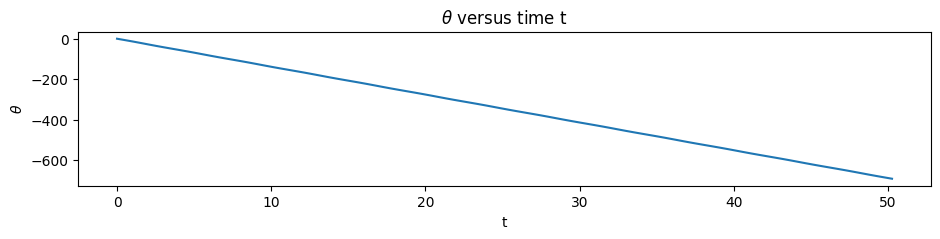

In [4]:
# Step 5: Explore with plotting

# Construct Plot
t_plot = np.linspace(t_min, t_max, 100)
theta_plot = sol.sol(t_plot)[0]
plt.figure(figsize=(11,2))
plt.plot(t_plot, theta_plot)
plt.xlabel("t")
plt.ylabel("$\\theta$")
plt.title("$\\theta$ versus time t")
plt.show()

In [5]:
# Step 6: Animate the motion of the pendulum

# Create pendulum animation
def create_pendulum_animation(t, x_pivot, y_pivot, x_lab, y_lab, l=1, show_traj=False, speed_factor=1.0):
    """
    Creates an animation of the pivot-driven pendulum.

    PARAMETERS:
    t : ndarray
        Time array.
    x_pivot : ndarray
        x-positions of the pivot over time.
    y_pivot : ndarray
        y-positions of the pivot over time.
    x_lab : ndarray
        x-positions of the pendulum bob in the lab frame over time.
    y_lab : ndarray
        y-positions of the pendulum bob in the lab frame over time.
    l : float, optional
        pendulum length (default is 1).
    show_traj : bool, optional
        toggle showing the trajectory of the pendulum bob (default is False).
    speed_factor : float, optional
        factor to scale the animation speed (default is 1.0).
        a value > 1.0 slows down the animation, < 1.0 speeds it up.

    RETURNS:
    anim : FuncAnimation
        matplotlib animation object.
    """
    fig, ax = plt.subplots(figsize=(4, 4)) # Increased figure size
    ax.set_xlim(np.min(x_pivot) - l, np.max(x_pivot) + l)
    ax.set_ylim(np.min(y_pivot) - l, np.max(y_pivot) + l)
    # ax.set_aspect('equal', adjustable='box')
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

    # Initialize plot elements
    pivot, = ax.plot([], [], 'o', color='black', markersize=8, label='Pivot')
    pendulum_arm, = ax.plot([], [], '-', color='black', lw=2, label='Pendulum Arm')
    pendulum_bob, = ax.plot([], [], 'o', color='red', markersize=12, label='Pendulum Bob')
    trajectory = None # Initialize trajectory to None

    if show_traj:
        trajectory, = ax.plot([], [], '-', color='gray', lw=1, alpha=0.5, label='Trajectory') # Add trajectory line

    def animate(i):
        # Update the positions of the plot elements
        pivot.set_data([x_pivot[i]], [y_pivot[i]]) # Pass as sequences
        pendulum_arm.set_data([x_pivot[i], x_lab[i]], [y_pivot[i], y_lab[i]])
        pendulum_bob.set_data([x_lab[i]], [y_lab[i]]) # Pass as sequences

        artists = [pivot, pendulum_arm, pendulum_bob] # List of artists to update

        if show_traj and trajectory:
             trajectory.set_data(x_lab[:i+1], y_lab[:i+1]) # Update trajectory data
             artists.append(trajectory) # Add trajectory to the list of artists

        return artists # Return all updated artists

    # Create the animation
    # Adjust the interval based on the average time step in t
    # This aims to make the animation speed consistent with the simulation time
    average_time_step = np.mean(np.diff(t))
    # Scale the interval by the speed_factor
    interval = average_time_step * 1000 * speed_factor # Convert to milliseconds and apply speed_factor.

    anim = FuncAnimation(fig, animate, frames=len(t), interval=interval, blit=True)
    plt.close(fig) # Close the initial figure to prevent it from displaying

    return anim

In [6]:
# Step 6: Animate the motion of the pendulum (continued)

# Animate motion
# Plot pendulum angle versus time
# Get coordinates for plotting
n_points = 300 # number of frames
t_plot = np.linspace(t_min, t_max, n_points)
theta_plot = sol.sol(t_plot)[0] # requires `dense_output=True` in `solve_ivp`
x_pivot, y_pivot = get_pivot_xy(t_plot, omega_d, x_p0, y_p0) # pivot coordinates
x_pendulum, y_pendulum = get_pendulum_xy(t_plot, theta_plot, l) # pendulum coordinates of pendulum (referenced to pivot point)
x_lab, y_lab = get_lab_xy(x_pivot, y_pivot, x_pendulum, y_pendulum) # pendulum coordinates in the lab frame

# Animation flags/parameters
show_traj = True # True --> show trajectory; False --> do not show trajectory
speed_factor = 5 # >1 --> slow down animation; <1 --> speed up animation

# create_pendulum_animation
pendulum_animation = create_pendulum_animation(t_plot, x_pivot, y_pivot, x_lab, y_lab, show_traj=show_traj, speed_factor=speed_factor) # create animation object with trajectory shown
HTML(pendulum_animation.to_html5_video()) # display animation

### Analytical Stability Analysis
* If the pendulum bob starts from rest (i.e. when $\theta_0 = 0$ and $\dot{\theta}_0 = 0$), the pendulum will remain stationary and motionless unless if there is a driving frequency being applied to the pivot point. For if there was a driving frequency being applied to the pivot point, even if the pendulum bob starts from rest, the pendulum will not stay stationary.
* For the equilibrium position to be stable, there should be no driving frequency applied to the pendulum system whatsoever. For the equilibrium position to be unstable, simply apply a driving frequency to the pendulum system.